In [1]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    
    def __init__(self, n_inputs):
        self.n_inputs = n_inputs
        self.weights = np.zeros(n_inputs)  # initialize weights to 0
        self.bias = 0                       # initialize bias to 0
    
    def H(self, z):
        return 1 if z >= 0 else 0
    
    def out(self, X):
        results = []
        for x in X:
            z = np.dot(self.weights, x) + self.bias
            results.append(self.H(z))
        return results
    
    def learn(self, data_learn, eta, epochs):
        for _ in range(epochs):
            for x, y in data_learn:
                z = np.dot(self.weights, x) + self.bias
                if y == 1 and z < 0:        # A+, predicted wrong
                    self.weights += eta * x
                    self.bias    += eta
                elif y == 0 and z >= 0:     # A-, predicted wrong
                    self.weights -= eta * x
                    self.bias    -= eta
    
    def plot_boundary(self):
        x1_vals = np.linspace(-0.5, 1.5, 200)
        x2_vals = np.linspace(-0.5, 1.5, 200)
        X1, X2 = np.meshgrid(x1_vals, x2_vals)
        
        Z = np.array([self.H(np.dot(self.weights, np.array([x1, x2])) + self.bias)
                      for x1, x2 in zip(X1.ravel(), X2.ravel())])
        Z = Z.reshape(X1.shape)
        
        plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
        plt.colorbar(label='Perceptron output')

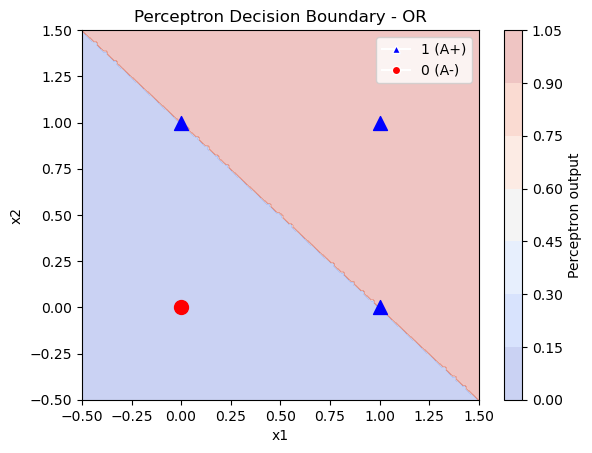


OR dataset:
Weights: [1. 1.], Bias: -1
  input=[1 1], predicted=1, expected=1
  input=[1 0], predicted=1, expected=1
  input=[0 1], predicted=1, expected=1
  input=[0 0], predicted=0, expected=0


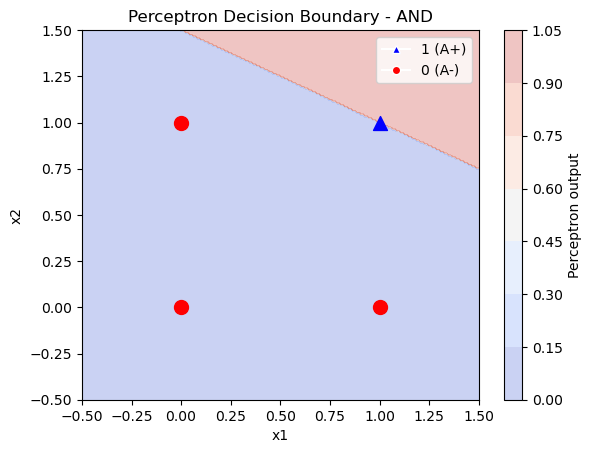


AND dataset:
Weights: [1. 2.], Bias: -3
  input=[1 1], predicted=1, expected=1
  input=[1 0], predicted=0, expected=0
  input=[0 1], predicted=0, expected=0
  input=[0 0], predicted=0, expected=0


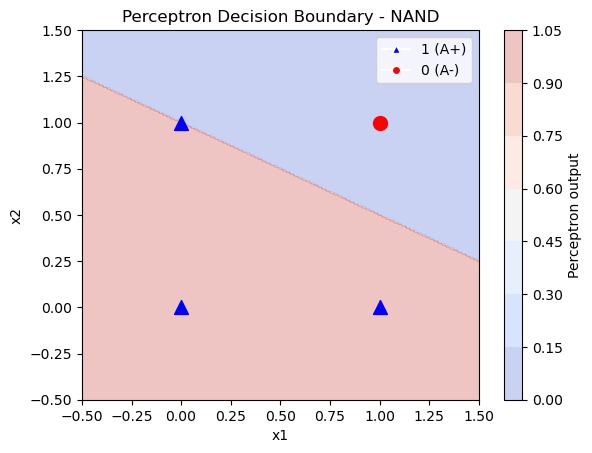


NAND dataset:
Weights: [-1. -2.], Bias: 2
  input=[1 1], predicted=0, expected=0
  input=[1 0], predicted=1, expected=1
  input=[0 1], predicted=1, expected=1
  input=[0 0], predicted=1, expected=1


In [2]:
# Datasets
X = np.array([[1,1],[1,0],[0,1],[0,0]])

Y_OR   = [1, 1, 1, 0]
Y_AND  = [1, 0, 0, 0]
Y_NAND = [0, 1, 1, 1]

datasets = {'OR': Y_OR, 'AND': Y_AND, 'NAND': Y_NAND}

for name, Y in datasets.items():
    # create and train perceptron
    p = Perceptron(n_inputs=2)
    data_learn = list(zip(X, Y))
    p.learn(data_learn, eta=1, epochs=10)
    
    # plot
    plt.figure()
    p.plot_boundary()
    
    # overlay data points
    for x, y in zip(X, Y):
        color = 'blue' if y == 1 else 'red'
        marker = '^' if y == 1 else 'o'
        plt.scatter(x[0], x[1], color=color, marker=marker, s=100, zorder=5)
    
    plt.title(f"Perceptron Decision Boundary - {name}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend(handles=[
        plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='blue', label='1 (A+)'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red',  label='0 (A-)')
    ])
    plt.show()
    
    # print results
    print(f"\n{name} dataset:")
    print(f"Weights: {p.weights}, Bias: {p.bias}")
    outputs = p.out(X)
    for x, pred, actual in zip(X, outputs, Y):
        print(f"  input={x}, predicted={pred}, expected={actual}")